In [1]:
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset,DataLoader
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [2]:
torch.manual_seed(42)

In [3]:
df = pd.read_csv("fmnist_small.csv")
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,9,0,0,0,0,0,0,0,0,0,...,0,7,0,50,205,196,213,165,0,0
1,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,1,0,0,0,...,142,142,142,21,0,3,0,0,0,0
3,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,8,0,0,0,0,0,0,0,0,0,...,213,203,174,151,188,10,0,0,0,0


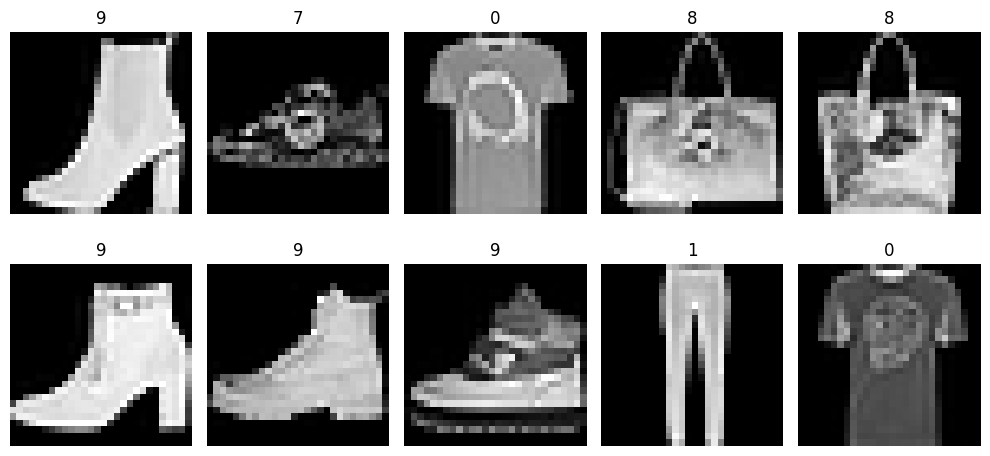

In [4]:
# visualizing image
fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i, ax in enumerate(axes.flat):
    label = df.iloc[i, 0]
    image = df.iloc[i, 1:].values.reshape(28, 28)

    ax.imshow(image, cmap="gray")
    ax.set_title(label)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [5]:
X = df.iloc[:,1:].values
y = df.iloc[:,0].values

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [7]:
X_train = X_train/255.0
X_test = X_test/255.0

In [8]:
class CustomDataset(Dataset):

    def __init__(self,features,labels):
        super().__init__()
        self.features = torch.tensor(features,dtype=torch.float32)
        self.labels = torch.tensor(labels,dtype=torch.long)

    def __len__(self):
        return len(self.features)

    def __getitem__(self, index):
        return self.features[index],self.labels[index]

In [9]:
train_dataset = CustomDataset(X_train,y_train)

In [10]:
len(train_dataset)

4800

In [11]:
test_dataset = CustomDataset(X_test,y_test)

In [12]:
train_loader = DataLoader(train_dataset,batch_size=32,shuffle=True)
test_loader = DataLoader(test_dataset,batch_size=32,shuffle=False)

In [ ]:
class MyNN(nn.Module):
    def __init__(self, num_features):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(num_features,128),
            nn.BatchNorm1d(),
            nn.ReLU(),
            nn.Dropout(p=0.3),
            nn.Linear(128,64),
            nn.BatchNorm1d(),
            nn.ReLU(),
            nn.Dropout(p=0.3),
            nn.Linear(64,10)
         )

    def forward(self,x):
        return self.model(x)

In [14]:
epochs = 100
learning_rate = 0.1

In [15]:
model = MyNN(X_train.shape[1])

criterion = nn.CrossEntropyLoss()

optimizer = optim.SGD(model.parameters(),lr=learning_rate)

In [16]:
for epoch in range(epochs):
    total_epoch_loss = 0
    for batch_feature,batch_labels in train_loader:
        #forward pass
        outputs = model(batch_feature)
        # loss calc
        loss = criterion(outputs,batch_labels)

        # back pass
        optimizer.zero_grad()
        loss.backward()

        # update grad
        optimizer.step()

        total_epoch_loss += loss.item()

    avg_loss = total_epoch_loss/len(train_loader)
    print(f"Epoch:{epoch+1}, Loss:{avg_loss}")
        

Epoch:1, Loss:1.459214724699656
Epoch:2, Loss:0.9097739056746165
Epoch:3, Loss:0.7812021579345068
Epoch:4, Loss:0.7018023713429768
Epoch:5, Loss:0.6547783829768499
Epoch:6, Loss:0.6045099807778994
Epoch:7, Loss:0.5788602554798126
Epoch:8, Loss:0.5522429458300273
Epoch:9, Loss:0.5387655051549276
Epoch:10, Loss:0.5191509669025739
Epoch:11, Loss:0.5037315685550372
Epoch:12, Loss:0.48370282451311747
Epoch:13, Loss:0.47234422514835994
Epoch:14, Loss:0.46811111489931745
Epoch:15, Loss:0.4496136716008186
Epoch:16, Loss:0.43989414085944495
Epoch:17, Loss:0.4291068720817566
Epoch:18, Loss:0.40783864110708234
Epoch:19, Loss:0.4064304399987062
Epoch:20, Loss:0.40406357193986575
Epoch:21, Loss:0.3708574868241946
Epoch:22, Loss:0.3773745390276114
Epoch:23, Loss:0.3679781375825405
Epoch:24, Loss:0.34998510738213856
Epoch:25, Loss:0.3474242578446865
Epoch:26, Loss:0.3523475823303064
Epoch:27, Loss:0.3363910379012426
Epoch:28, Loss:0.3397459701200326
Epoch:29, Loss:0.3321163700520992
Epoch:30, Loss:0.

In [17]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for batch_features, batch_labels in test_loader:

        outputs = model(batch_features)

        _, predicted = torch.max(outputs, 1)

        total += batch_labels.size(0)
        correct += (predicted == batch_labels).sum().item()

accuracy = 100 * correct / total
print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 85.00%


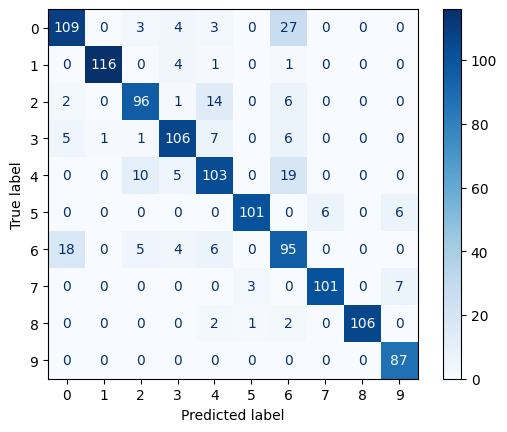

In [18]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for batch_features, batch_labels in test_loader:

        outputs = model(batch_features)
        _, predicted = torch.max(outputs, 1)

        y_true.extend(batch_labels.numpy())
        y_pred.extend(predicted.numpy())

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.show()

In [19]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.75      0.78       146
           1       0.99      0.95      0.97       122
           2       0.83      0.81      0.82       119
           3       0.85      0.84      0.85       126
           4       0.76      0.75      0.75       137
           5       0.96      0.89      0.93       113
           6       0.61      0.74      0.67       128
           7       0.94      0.91      0.93       111
           8       1.00      0.95      0.98       111
           9       0.87      1.00      0.93        87

    accuracy                           0.85      1200
   macro avg       0.86      0.86      0.86      1200
weighted avg       0.86      0.85      0.85      1200



In [20]:
losses = []

for epoch in range(epochs):

    total_epoch_loss = 0

    for batch_features, batch_labels in train_loader:

        outputs = model(batch_features)
        loss = criterion(outputs, batch_labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_epoch_loss += loss.item()

    losses.append(total_epoch_loss / len(train_loader))

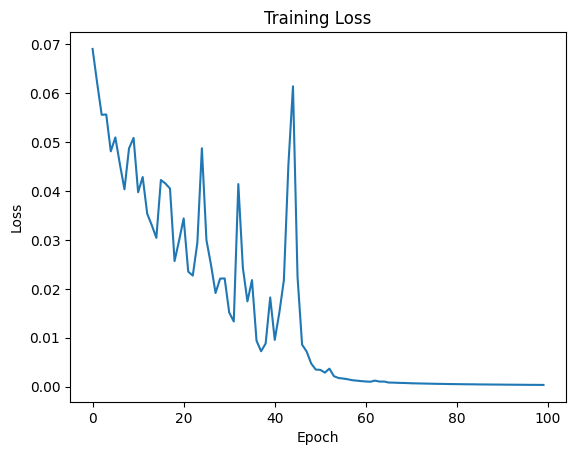

In [21]:
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()